# Imaginary time propagation - A Gross-Pitaevskii ground-state solver

This small package is built on my previous package '[bloch_hamiltonian](https://github.com/GuillotMartin/bloch_schrodinger)'. It is a specialized solver of the 2D [Gross-Pitaevskii](https://en.wikipedia.org/wiki/Gross%E2%80%93Pitaevskii_equation) equation meant to find the ground state of the time-independant Gross-Pitaevskii equation
$$\hat{H} \psi(\bf{r}) = \left[ -\frac{\hbar^2}{2m} \nabla^2 + V(\bf{r}) + g |\psi|^2 \psi(\bf{r}) \right] = 0$$

This solver uses an [imaginary time evolution method](https://matterwavex.com/imaginary-time-evolution-method-for-finding-the-ground-state/), numerically implemented by a [RKF45 adaptative method](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta%E2%80%93Fehlberg_method). The solver supports potential landscapes drawns by the 'Potential' class of the 'bloch_hamiltonian' package and multi-field equations, and it is mainly intended for parameter space exploration.

This package consists in a single class `GroundState`, which inherits most of its methods and attributes from the `Solver` class of bloch_hamiltonian. In this tutorial, we will review its main method 'solve' and use it to observe the transition of a Bose-Einstein condensate from the ideal-gas to the [Thomas-Fermi](https://en.wikipedia.org/wiki/Thomas%E2%80%93Fermi_model) limit.

## Building a potential and initializing the solver

First, let's build an harmonic potential trap for our condensate.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from BECs.groundstate import GroundState


# --- Instancing a flat potential ---
trap = Potential(
    unitvecs  =[[3,0],[0,3]],
    resolution = (100,100),
    v0 = 2250/2
)

# --- Shaping the potential ----
omega = 1000 # The harmonic trap strength ω

trap.circle(
    center = (0,0),
    radius=6,
    value = (trap.x**2 + trap.y**2) * omega / 2 # The potential profile is a circularily symmetric harmonic trap
)

# --- Instancing ---
# A single parameter will vary, the interaction strength g
g = create_parameter('g', np.linspace(0,1,11))

alpha = 1 # α = hbar²/2m = 1 as we set m and hbar equal to 1

ground = GroundState( # The Groundstate class is derived from the Solver class, and can be instanciated with: 
    potentials = trap, # a potential landscape (or a list thereof)
    alphas = alpha, # a kinetic term α (or a list thereof)
    gs = g # an interaction strength term g (or a list thereof)
)

Once the solver is instanced, one simply has to call the `solve` class method, specifying an atom population number for wavefunction normalization. Here, we take $N = 1000$.

In [27]:

energies, groundstates = ground.solve(population = 1000, tol = 1e-8) # A few other keyword arguments can be passed (see documentation).

Computing the initial guesses


100%|██████████| 11/11 [00:00<00:00, 13.68it/s]


Computing the ground states


100%|██████████| 11/11 [00:05<00:00,  2.02it/s]


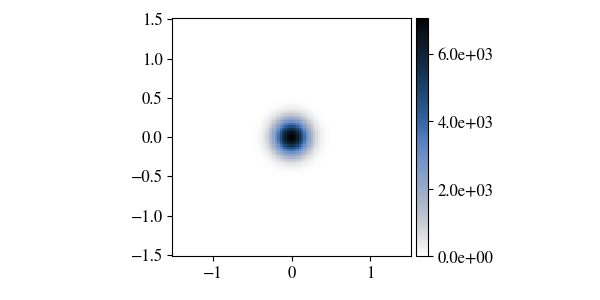

In [28]:
%matplotlib widget

from bloch_schrodinger.plotting import get_template, plot_eigenvector, energy_levels
temp = get_template('amplitude')
temp["contourkwargs"]["levels"] = np.arange(1,10)*100 # Where to put the contour lines of the potential
temp["contourkwargs"]["colors"] = "white"
plot_eigenvector(
    [[abs(groundstates)**2]],
    [[trap]],
    [[temp]]
)
plt.show()

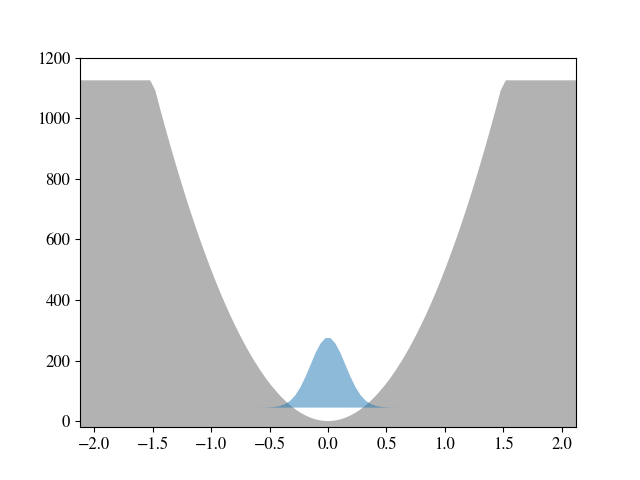

In [29]:
import matplotlib.pyplot as plt
density = abs(groundstates)**2

energy_levels(
    energies.expand_dims('band')/1000, #dividing by the population to get the energy/atom
    density.expand_dims('band') * energies, # rescaling by energy to take into account the spreading of the wavefunction
    trap,
    frac = 0.2,
    ymin = -20,
    ymax = 1200
)
plt.show()

With the energy_level function, we can clearly the 2 effects an increase in interaction strength has. First, the energy of the ground state increases, which is trivial to understand, and secondly, the density profile of the ground state changes. In the Thomas-Fermi limit, the density profile $n$ will actually match perfectly the shape of the potential:
$$n(\bf{r}) = \text{max} \left[ \frac{\mu - V(\bf{r})}{g} \right]$$
With $\mu$ the energy of the ground state, equal to the chemical potential. We can further highlight this by performing the same computation for a square well.

Computing the initial guesses


100%|██████████| 11/11 [00:02<00:00,  5.39it/s]


Computing the ground states


100%|██████████| 11/11 [00:02<00:00,  4.15it/s]


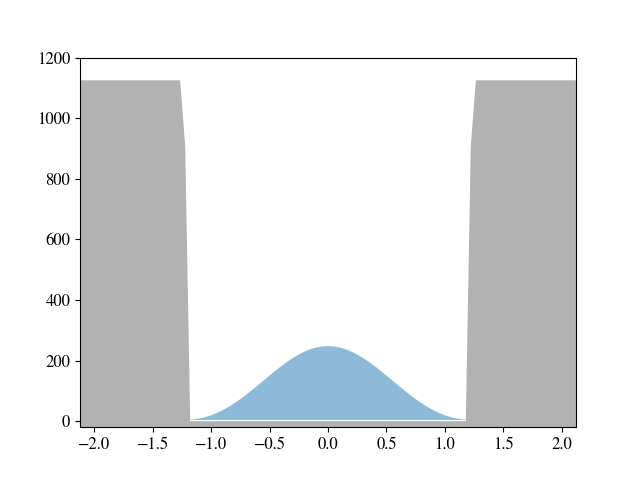

In [31]:
# --- Instancing a flat potential ---
square_trap = Potential(
    unitvecs  =[[3,0],[0,3]],
    resolution = (100,100),
    v0 = 2250/2
)

# --- Shaping the potential ----
square_trap.circle(
    center = (0,0),
    radius=1.2,
)

# --- Instancing ---
# A single parameter will vary, the interaction strength g
g = create_parameter('g', np.linspace(0,2,11))

alpha = 1 # α = hbar²/2m = 1 as we set m and hbar equal to 1

square_ground = GroundState( # The Groundstate class is derived from the Solver class, and can be instanciated with: 
    potentials = square_trap, # a potential landscape (or a list thereof)
    alphas = alpha, # a kinetic term α (or a list thereof)
    gs = g # an interaction strength term g (or a list thereof)
)

square_energies, square_groundstates = square_ground.solve(population = 1000, tol = 1e-8) # A few other keyword arguments can be passed (see documentation).
square_density = abs(square_groundstates)**2

energy_levels(
    square_energies.expand_dims('band')/1000, #dividing by the population to get the energy/atom
    square_density.expand_dims('band'), # No rescaling here as the trap is square
    square_trap,
    frac = 0.2,
    ymin = -20,
    ymax = 1200
)
plt.show()